In [2]:
!pip install --upgrade scpviz

   ---------------------------------------- 0.0/247.7 kB ? eta -:--:--
   ---------------------------------------- 247.7/247.7 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: scpviz
    Found existing installation: scpviz 1.0.0
    Uninstalling scpviz-1.0.0:
      Successfully uninstalled scpviz-1.0.0


In [1]:
from scpviz import pAnnData as pAnnData
from scpviz import plotting as scplt
from scpviz import utils as scutils

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='paper', style='ticks')

In [2]:
from scpviz import setup as scsetup

scsetup.print_versions()

scpviz version: 1.0.1
Date and time:  2026-07-10 00:59:58
Core dependencies:
  numpy 2.4.6
  pandas 2.3.3
  matplotlib 3.10.8
  seaborn 0.13.2
  upsetplot 0.9.0
  scikit-learn 1.6.1
  scipy 1.17.1
  umap-learn 0.5.12
  adjustText 1.3.0
  anndata 0.12.10
  requests 2.33.1
  matplotlib_venn 1.1.2
  pyarrow 23.0.1
  scanpy 1.11.5
  gseapy 1.1.13
  openpyxl 3.1.5
  biopython 1.83
Optional [sc]:
  directlfq 0.3.2
  pimms-learn 0.5.2
  harmonypy 0.0.10
  leidenalg 0.10.2
  igraph 0.11.9
  scikit-misc 0.5.1
Optional [notebook]:
  IPython 8.22.2
Optional [dev]:
  pytest 8.4.1
  coverage 7.10.7
  flake8 not installed
  pytest-cov 7.0.0


## pd

In [2]:
obs_columns = ['Sample','cellline','condition']

pdata = pAnnData.import_data(source_type='pd', prot_file = 'pd_prot.txt', pep_file = 'pd_pep.txt',obs_columns=obs_columns)


🧭 [USER] Importing data of type [pd]
--------------------------
Starting import [Proteome Discoverer]

Source file: pd_prot.txt / pd_pep.txt
Number of files: 12
Proteins: 4988
Peptides: 30920

ℹ️ Using 'Modifications' for modification annotation.

ℹ️ 25 proteins with missing gene names.
     🌐 [API] Querying UniProt for batch 1/1 (25 proteins) [fields: accession, gene_primary]
     ✅ Retrieved UniProt metadata for 25 entries.
     ✅ [OK] Recovered 24 gene name(s) from UniProt. Genes found:
         TUFM, HDLBP, AMPD2, MYG1, HSD17B11, PCM1, NEFH, OXA1L, TRMT5, SLC4A1AP...
     ⚠️ [WARN] 1 gene name(s) still missing. Assigned as 'UNKNOWN_<accession>' for:
         Q6ZSR9
     💡 Tip: You can update these using `pdata.update_identifier_maps({'GENE': 'ACCESSION'}, on='protein', direction='reverse', overwrite=True)`

ℹ️ Removed 64 empty proteins (all-NaN or all-zero). Proteins: P49448, P53675, Q8IZP2, Q15173, O43402, P40123, O95954, O75382, Q9NYQ6, Q14BN4, ...
     ℹ️ [INFO] Using global q-v

In [5]:
# by accession
df = scutils.get_peptides_for_accessions(pdata, ["P34932"])

# by gene name
df = scutils.get_peptides_for_accessions(pdata, ["HSPA4"])

df.head()
# columns: accession, peptide_id, sequence

,accession,peptide_id,sequence
0,P34932,[K].AESEEMETSQAGSK.[D],[K].AESEEMETSQAGSK.[D]
1,P34932,[K].EDQYDHLDAADMTK.[V],[K].EDQYDHLDAADMTK.[V]
2,P34932,[K].ELSTTLNADEAVTR.[G],[K].ELSTTLNADEAVTR.[G]
3,P34932,[K].ETAESVLK.[K],[K].ETAESVLK.[K]
4,P34932,[K].FLEMCNDLLAR.[V] MOD:1xCarbamidomethyl [C5],[K].FLEMCNDLLAR.[V] MOD:1xCarbamidomethyl [C5]


In [4]:
pdata

pAnnData object

Summary:
  Groups: Sample, cellline, condition, mbr_count
  Avg proteins/sample: 4720.3
  Avg protein quant: 0.96
  Samples < 50% quant: 0

Protein (shape: 12 files × 4924 proteins)
  obs:    Sample, cellline, condition, protein_quant, protein_count...
  var:    Proteins Unique Sequence ID, Checked, Protein FDR Confidence: Combined, Master, Accession...
  obsm:   —
  layers: X_raw, X_mbr

Peptide: None

RS:
  None

STRING Enrichment:
  —

,Class,CV,Accession,Genes,CV_pct
0,AS_kd,0.111666,P07437,TUBB,11.166621
1,AS_kd,0.091308,P78527,PRKDC,9.130800
2,AS_kd,0.083945,Q13813,SPTAN1,8.394470
3,AS_kd,0.185076,Q13813-3,SPTAN1,18.507585
4,AS_kd,0.190703,P68371,TUBB4B,19.070313
...,...,...,...,...,...
19691,BE_sc,0.480168,Q96T58,SPEN,48.016842
19692,BE_sc,0.410469,Q9H1K6,TLNRD1,41.046920
19693,BE_sc,0.091039,O14646,CHD1,9.103884
19694,BE_sc,0.166006,P17481,HOXB8,16.600581


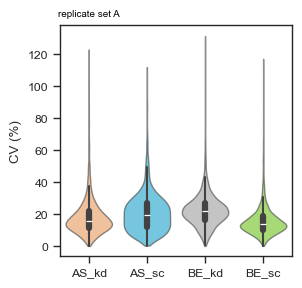

In [ ]:
# Basic (unchanged call signature)
fig, ax = plt.subplots(figsize=(3,3))
scplt.plot_cv(ax, pdata, classes=["cellline", "condition"])

# With annotations
fig, ax = plt.subplots(figsize=(3,3))
scplt.plot_cv(
    ax, pdata, classes=["cellline", "condition"],
    show_n=True,
    annotate="median",
    annotate_kwargs={"fontsize": 7},
)

# Custom labels
fig, ax = plt.subplots(figsize=(3,3))
scplt.plot_cv(ax, pdata, classes=["cellline", "condition"], annotate={"AS_kd": "replicate set A"})

# Data export
cv_df = scplt.plot_cv(None, pdata, classes=["cellline", "condition"], return_df=True)
cv_df
# cv_df has columns: Class, CV, CV_pct, ...

     ℹ️ [INFO] Computing PCA (force=False)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=1.71e+06). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (12, 4924)
   🔸 AFTER  (samples × proteins): (12, 4282)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 47.70% , 23.09%


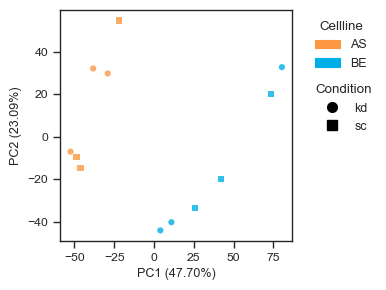

In [6]:
fig, ax = plt.subplots(figsize=(3,3))
ax = scplt.plot_pca(ax, pdata, color='cellline',marker_shape='condition', edge_cmap="cellline")

scplt.shift_legend(ax)

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=1.71e+06). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (12, 4924)
   🔸 AFTER  (samples × proteins): (12, 4282)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 47.70% , 23.09%


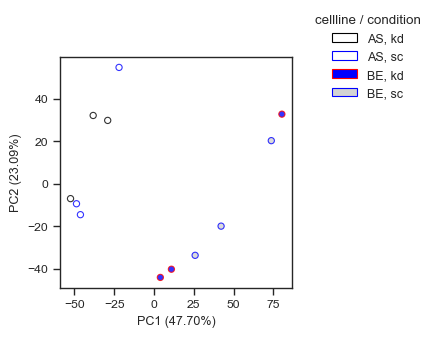

In [8]:
# Tuple-key mapping: (cellline, condition) -> face + edge (AS/BE × kd/sc)
mapping_keys = ["cellline", "condition"]
mapping = {
    ("AS", "kd"): {"color": "white", "edge_color": "black"},
    ("AS", "sc"): {"color": "white", "edge_color": "blue"},
    ("BE", "kd"): {"color": "blue", "edge_color": "red"},
    ("BE", "sc"): {"color": "lightgrey", "edge_color": "blue"},
}

fig, ax = plt.subplots(figsize=(3, 3))
ax = scplt.plot_pca(
    ax,
    pdata,
    mapping_keys=mapping_keys,
    mapping=mapping,
    mapping_on_missing='warn',
    force=True,
)
scplt.shift_legend(ax)


Classes: cellline, Values: AS
Filter query: ((adata.obs['cellline'] == 'AS'))
Classes: cellline, Values: BE
Filter query: ((adata.obs['cellline'] == 'BE'))


(<matplotlib_venn._common.VennDiagram at 0x23ae058b950>,
 (<matplotlib.patches.Circle at 0x23ae0fe6590>,
  <matplotlib.patches.Circle at 0x23ae0ff7110>))

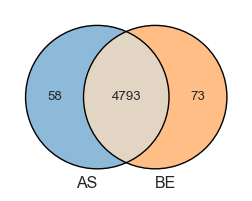

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
scplt.plot_venn(
    ax, pdata, classes="cellline",
    set_colors=["#1f77b4", "#ff7f0e"]
)

In [7]:
scutils.get_classlist(pdata.prot, classes="cellline")

['AS', 'BE']
Categories (2, object): ['AS', 'BE']

Classes: cellline, Values: AS
Filter query: ((adata.obs['cellline'] == 'AS'))
Classes: cellline, Values: BE
Filter query: ((adata.obs['cellline'] == 'BE'))


<Axes: title={'center': 'Coefficient of Variation (CV) by Class'}, xlabel='Class', ylabel='CV'>

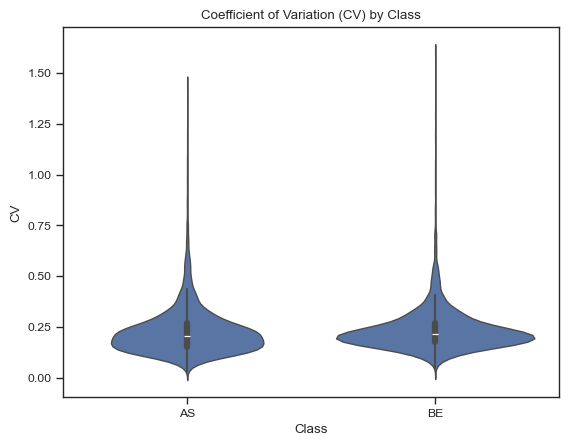

In [3]:
fig, ax = plt.subplots()

scplt.plot_cv(ax, pdata, classes="cellline")

<Axes: xlabel='cellline', ylabel='protein_count'>

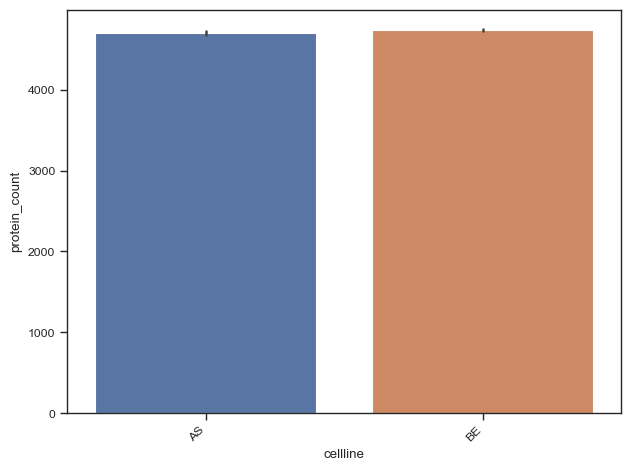

In [7]:
fig, ax = plt.subplots()

scplt.plot_summary(ax, pdata, classes="cellline")

In [3]:
scutils.convert_identifiers(["P40925"], "accession", "gene", return_type="dict")

🔍 [SEARCH] Converting from 'accession' to ['gene'] for 1 identifiers...
     ℹ️ No pdata provided — querying UniProt for all target fields.
     🌐 [API] Querying UniProt for batch 1/1 (1 proteins) [fields: accession, gene_primary]
     ✅ Retrieved UniProt metadata for 1 entries.
     ✅ 1/1 identifiers successfully converted (0 local, 1 via UniProt).


{'P40925': {'gene': 'MDH1'}}

In [4]:
scutils.convert_identifiers(["P40925", "P55072"], "accession", ["gene", "string", "organism_id"], return_type="dict")

🔍 [SEARCH] Converting from 'accession' to ['gene', 'string', 'organism_id'] for 2 identifiers...
     ℹ️ No pdata provided — querying UniProt for all target fields.
     🌐 [API] Querying UniProt for batch 1/1 (2 proteins) [fields: accession, xref_string, gene_primary, organism_id]
     ✅ Retrieved UniProt metadata for 2 entries.
     ✅ 2/2 identifiers successfully converted (0 local, 2 via UniProt).


{'P40925': {'gene': 'MDH1', 'string': nan, 'organism_id': 9606},
 'P55072': {'gene': 'VCP',
  'string': '9606.ENSP00000351777',
  'organism_id': 9606}}

In [5]:
scutils.convert_identifiers(["P40925", "P55072", "P04637"], "accession", ["gene", "string", "organism_id"], return_type="df")

🔍 [SEARCH] Converting from 'accession' to ['gene', 'string', 'organism_id'] for 3 identifiers...
     ℹ️ No pdata provided — querying UniProt for all target fields.
     🌐 [API] Querying UniProt for batch 1/1 (3 proteins) [fields: accession, xref_string, gene_primary, organism_id]
     ✅ Retrieved UniProt metadata for 3 entries.
     ✅ 3/3 identifiers successfully converted (0 local, 3 via UniProt).


,accession,gene,string,organism_id
0,P40925,MDH1,NaN,9606
1,P55072,VCP,9606.ENSP00000351777,9606
2,P04637,TP53,9606.ENSP00000269305,9606


In [8]:
scutils.convert_identifiers(["P40925", "P55072", "P04637"], "accession", ["gene"], return_type="df", pdata=pdata)


🔍 [SEARCH] Converting from 'accession' to ['gene'] for 3 identifiers...
     ℹ️ Using cached mapping from pdata (no UniProt queries).
     ✅ 3/3 identifiers successfully converted (3 local, 0 via UniProt).


,accession,gene
0,P40925,MDH1
1,P55072,VCP
2,P04637,TP53


In [10]:
scutils.convert_identifiers(["MDH1", "VCP", "TP53"], "gene", ["accession", "string", "organism_id"], return_type="df", pdata=pdata)


🔍 [SEARCH] Converting from 'gene' to ['accession', 'string', 'organism_id'] for 3 identifiers...
     ℹ️ Using cached mapping for gene/accession; UniProt lookup required for: string, organism_id.
     🌐 [API] Querying UniProt for batch 1/1 (3 proteins) [fields: accession, xref_string, organism_id, gene_primary]
     ✅ Retrieved UniProt metadata for 3 entries.
     ✅ 3/3 identifiers successfully converted (0 local, 3 via UniProt).


,gene,accession,string,organism_id
0,MDH1,P40925,NaN,9606
1,VCP,P55072,9606.ENSP00000351777,9606
2,TP53,P04637,9606.ENSP00000269305,9606


In [7]:
scutils.convert_identifiers(["P40925", "P55072", "P04637"], "accession", ["gene", "string", "organism_id"], return_type="df", pdata=pdata)


🔍 [SEARCH] Converting from 'accession' to ['gene', 'string', 'organism_id'] for 3 identifiers...
     ℹ️ Using cached mapping for gene/accession; UniProt lookup required for: string, organism_id.
     🌐 [API] Querying UniProt for batch 1/1 (3 proteins) [fields: accession, xref_string, gene_primary, organism_id]
     ✅ Retrieved UniProt metadata for 3 entries.
     ✅ 3/3 identifiers successfully converted (0 local, 3 via UniProt).


,accession,gene,string,organism_id
0,P40925,MDH1,NaN,9606
1,P55072,VCP,9606.ENSP00000351777,9606
2,P04637,TP53,9606.ENSP00000269305,9606


In [5]:
pdata

pAnnData object

Summary:
  Groups: Sample, cellline, condition, mbr_count
  Avg proteins/sample: 4720.3
  Avg protein quant: 0.96
  Samples < 50% quant: 0

Protein (shape: 12 files × 4924 proteins)
  obs:    Sample, cellline, condition, protein_quant, protein_count...
  var:    Proteins Unique Sequence ID, Checked, Protein FDR Confidence: Combined, Master, Accession...
  obsm:   —
  layers: X_raw, X_mbr

Peptide: None

RS:
  None

STRING Enrichment:
  —

## diann

In [3]:
pdata_diann = pAnnData.import_data(source_type='diann', report_file = '../tests/test_diann.parquet', obs_columns=['user', 'date', 'ms', 'acquisition', 'faims', 'column', 'gradient', 'amount', 'region', 'id'])

🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: ../tests/test_diann.parquet
Number of files: 12
Proteins: 2251
Peptides: 7688

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (2251, 7688) (proteins × peptides), sparsity: 99.95%
   - Proteins with ≥2 *unique* linked peptides: 1217/2251
   - Peptides linked to ≥2 proteins: 158/7688
   - Mean peptides per protein: 3.53
   - Mean proteins per peptide: 1.03
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


In [3]:
pdata_diann.summary

,user,date,ms,acquisition,faims,column,gradient,amount,region,id,protein_quant,protein_count,protein_abundance_sum,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_01,MP,20250219,OA,DIA,FAIMS,TS25,30min,sc,LCM-Cortex,01,0.786317,1770,8.422291e+08,0.739984,5689,2.601713e+09,1121
MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_02,MP,20250219,OA,DIA,FAIMS,TS25,30min,sc,LCM-Cortex,02,0.751222,1691,1.232896e+09,0.682102,5244,3.473356e+09,1107
MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_03,MP,20250219,OA,DIA,FAIMS,TS25,60minOLDgrad,sc,LCM-Cortex,03,0.693025,1560,6.879191e+08,0.568028,4367,2.088099e+09,1056
MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cortex_02,MP,20250219,OA,DIA,FAIMS,TS25,60min,sc,LCM-Cortex,02,0.613505,1381,1.069634e+09,0.499089,3837,2.651975e+09,841
MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_01,MP,20250219,OA,DIA,FAIMS,TS25,60minOLDgrad,sc,LCM-Cortex,01,0.343403,773,1.272601e+09,0.260666,2004,3.585534e+09,556
MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_01,MP,20250219,OA,DIA,FAIMS,TS25,24min,sc,LCM-Cortex,01,0.350955,790,1.133656e+09,0.255983,1968,2.934632e+09,591
MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_02,MP,20250219,OA,DIA,FAIMS,TS25,24min,sc,LCM-Cortex,02,0.266548,600,1.059415e+09,0.187955,1445,2.167836e+09,452
MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_03,MP,20250219,OA,DIA,FAIMS,TS25,24min,sc,LCM-Cortex,03,0.310084,698,1.475957e+09,0.246358,1894,3.187479e+09,499
MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_03,MP,20250219,OA,DIA,FAIMS,TS25,30min,sc,LCM-Cortex,03,0.369614,832,2.002864e+09,0.290713,2235,5.320580e+09,621
MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cortex_03,MP,20250219,OA,DIA,FAIMS,TS25,60min,sc,LCM-Cortex,03,0.429587,967,1.162630e+09,0.328824,2528,2.449537e+09,711


In [10]:
pdata_diann.prot.var

,Genes,Global_Q_value,peptides_per_protein,unique_peptides,Found In: MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_01,Found In: MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_02,Found In: MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_03,Found In: MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cortex_02,Found In: MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_01,Found In: MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_01,...,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_03,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cortex_02,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_01,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_01,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_02,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cortex_03,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_03,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cortex_03,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cortex_01,Significant In: MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_LCM-Cortex_02
Q9R1T4,Septin6,0.000668,7,7,True,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
P97807,Fh,0.000668,6,6,True,True,True,True,False,False,...,True,False,False,False,False,False,False,True,False,False
Q9CZW5,Tomm70,0.000668,3,3,True,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
Q9CRB9,Chchd3,0.000668,5,5,True,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
Q8C1B7,Septin11,0.000668,3,3,True,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P52430,Pon1,0.000668,1,1,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
P61924,Copz1,0.000668,1,1,True,True,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
Q9R0R1,Meltf,0.001954,1,1,False,False,True,True,True,False,...,True,True,True,False,False,False,False,True,False,False
Q6PF93,Pik3c3,0.022694,1,1,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
pdata_diann.get_peptide_properties(accessions=['Septin11','Tomm70'])

,accession,peptide_id,peptide_sequence,gravy,molecular_weight,isoelectric_point
0,Q8C1B7,AAAQLLQSQAQQSGAQQTK3,AAAQLLQSQAQQSGAQQTK,-0.763158,1957.1065,8.795051
1,Q8C1B7,NLSLSGHVGFDSLPDQLVNK3,NLSLSGHVGFDSLPDQLVNK,-0.150000,2140.3520,5.210851
2,Q8C1B7,SYELQESNVR2,SYELQESNVR,-1.340000,1224.2772,4.529238
3,Q9CZW5,AAAFEQLQK2,AAAFEQLQK,-0.266667,1005.1251,6.046100
4,Q9CZW5,GFEEIIK2,GFEEIIK,0.071429,834.9559,4.531398
5,Q9CZW5,GLLQLQWK2,GLLQLQWK,-0.100000,985.1800,8.750052


## check

In [6]:
pdata_diann

pAnnData object

Summary:
  Groups: user, date, ms, acquisition, faims, column, gradient, amount, region, id
  Avg proteins/sample: 968.2
  Avg protein quant: 0.43
  Samples < 50% quant: 8

Protein (shape: 12 files × 2251 proteins)
  obs:    user, date, ms, acquisition, faims...
  var:    Genes, Global_Q_value, peptides_per_protein, unique_peptides, Found In: MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_01...
  obsm:   —
  layers: X_raw, X_qval

Peptide (shape: 12 files × 7688 peptides)
  obs:    user, date, ms, acquisition, faims...
  var:    Genes, Protein.Group, Precursor.Charge, Modified.Sequence, Stripped.Sequence...
  obsm:   —
  layers: X_raw, X_qval, X_precursor

RS (shape: 2251 proteins × 7688 peptides)
  Avg peptides/protein: 3.53
  Avg unique peptides : 3.35
  Proteins with ≥2 unique peptides: 54.1%

STRING Enrichment:
  —

In [7]:
pdata_diann.normalize(method='directlfq')

🧭 [USER] Running directlfq normalization on peptide-level data.
     ℹ️ Note: please be patient, directlfq can take a minute to run depending on data size. Output files will be produced.


2026-07-09 02:44:27,400 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-09 02:44:27,539 - directlfq.lfq_manager - INFO - Performing sample normalization.


     ℹ️ [INFO] Expanded multi-protein peptide groups: 7688 → 7943 rows.


2026-07-09 02:44:27,542 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-07-09 02:44:30,645 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-09 02:44:30,648 - directlfq.protein_intensity_estimation - INFO - 2141 lfq-groups total
2026-07-09 02:44:31,970 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-09 02:44:46,136 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-09 02:44:46,137 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-09 02:44:46,530 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


In [8]:
pdata_diann

pAnnData object

Summary:
  Groups: user, date, ms, acquisition, faims, column, gradient, amount, region, id
  Avg proteins/sample: 882.7
  Avg protein quant: 0.39
  Samples < 50% quant: 8

Protein (shape: 12 files × 2251 proteins)
  obs:    user, date, ms, acquisition, faims...
  var:    Genes, Global_Q_value, peptides_per_protein, unique_peptides, Found In: MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_01...
  obsm:   —
  layers: X_raw, X_qval, X_norm_directlfq

Peptide (shape: 12 files × 7688 peptides)
  obs:    user, date, ms, acquisition, faims...
  var:    Genes, Protein.Group, Precursor.Charge, Modified.Sequence, Stripped.Sequence...
  obsm:   —
  layers: X_raw, X_qval, X_precursor

RS (shape: 2251 proteins × 7688 peptides)
  Avg peptides/protein: 3.53
  Avg unique peptides : 3.35
  Proteins with ≥2 unique peptides: 54.1%

STRING Enrichment:
  —

In [9]:
pdata_diann_copy = pdata_diann.copy()
pdata_diann_copy

pAnnData object

Summary:
  Groups: user, date, ms, acquisition, faims, column, gradient, amount, region, id
  Avg proteins/sample: 882.7
  Avg protein quant: 0.39
  Samples < 50% quant: 8

Protein (shape: 12 files × 2251 proteins)
  obs:    user, date, ms, acquisition, faims...
  var:    Genes, Global_Q_value, peptides_per_protein, unique_peptides, Found In: MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cortex_01...
  obsm:   —
  layers: X_raw, X_qval, X_norm_directlfq

Peptide (shape: 12 files × 7688 peptides)
  obs:    user, date, ms, acquisition, faims...
  var:    Genes, Protein.Group, Precursor.Charge, Modified.Sequence, Stripped.Sequence...
  obsm:   —
  layers: X_raw, X_qval, X_precursor

RS (shape: 2251 proteins × 7688 peptides)
  Avg peptides/protein: 3.53
  Avg unique peptides : 3.35
  Proteins with ≥2 unique peptides: 54.1%

STRING Enrichment:
  —

## continue

In [14]:
df = scutils.get_peptides_for_accessions(
    pdata_diann,
    ["Q9CRB9"],
    sequence_from="Stripped.Sequence",  # or "Modified.Sequence"
)

df

,accession,peptide_id,sequence
0,Q9CRB9,AAANEQLTR2,AAANEQLTR
1,Q9CRB9,LSENVIDR2,LSENVIDR
2,Q9CRB9,RVTFEADENENITVVK3,RVTFEADENENITVVK
3,Q9CRB9,VAEELALEQAK2,VAEELALEQAK
4,Q9CRB9,VTTEEYQK2,VTTEEYQK


In [5]:
# Pick a well-detected gene — adjust if needed
gene = "Gapdh"  # or use an accession: poi = pdata_diann.prot.var_names[0]

df = pdata_diann.get_abundance(namelist=[gene], on="protein", log=False, all_matches=True)
print(f"Resolved accessions: {df['accession'].unique()}")

# Per-sample abundance (max across isoforms if multiple)
sample_abund = (
    df.groupby("cell", as_index=False)["abundance"]
    .max()
    .rename(columns={"cell": "sample"})
    .sort_values("abundance", ascending=False)
)
sample_abund

Resolved accessions: ['P16858']


,sample,abundance
4,MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cor...,2.383153e+06
3,MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cor...,1.723338e+06
9,MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cor...,8.839954e+05
11,MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cor...,8.747252e+05
8,MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_...,7.459440e+05
2,MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cor...,7.448816e+05
6,MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_...,7.094672e+05
0,MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cor...,6.486238e+05
7,MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_...,5.969108e+05
10,MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cor...,5.166548e+05


In [6]:
# Optional: merge with metadata for context
meta_cols = [c for c in ["region", "amt", "amount", "gradient", "replicate", "user"]
             if c in pdata_diann.prot.obs.columns]
sample_abund.merge(
    pdata_diann.prot.obs[meta_cols],
    left_on="sample",
    right_index=True,
)

,sample,abundance,region,amount,gradient,user
4,MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cor...,2.383153e+06,LCM-Cortex,sc,30min,MP
3,MP_20250219_OA_DIA_FAIMS_TS25_30min_sc_LCM-Cor...,1.723338e+06,LCM-Cortex,sc,30min,MP
9,MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cor...,8.839954e+05,LCM-Cortex,sc,60min,MP
11,MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cor...,8.747252e+05,LCM-Cortex,sc,60min,MP
8,MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_...,7.459440e+05,LCM-Cortex,sc,60minOLDgrad,MP
2,MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cor...,7.448816e+05,LCM-Cortex,sc,24min,MP
6,MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_...,7.094672e+05,LCM-Cortex,sc,60minOLDgrad,MP
0,MP_20250219_OA_DIA_FAIMS_TS25_24min_sc_LCM-Cor...,6.486238e+05,LCM-Cortex,sc,24min,MP
7,MP_20250219_OA_DIA_FAIMS_TS25_60minOLDgrad_sc_...,5.969108e+05,LCM-Cortex,sc,60minOLDgrad,MP
10,MP_20250219_OA_DIA_FAIMS_TS25_60min_sc_LCM-Cor...,5.166548e+05,LCM-Cortex,sc,60min,MP


In [7]:
abund = sample_abund["abundance"].replace(0, np.nan).dropna()
print(abund.describe())

# Example: keep top ~half of detected samples
threshold = abund.median()
print(f"Using min_abundance = {threshold:.2g}")

count    1.200000e+01
mean     8.966716e+05
std      5.753284e+05
min      4.577838e+05
25%      5.768468e+05
50%      7.271744e+05
75%      8.770428e+05
max      2.383153e+06
Name: abundance, dtype: float64
Using min_abundance = 7.3e+05


In [9]:
high = pdata_diann.filter_sample(poi=gene, min_abundance=threshold, return_copy=True)
print(f"Before: {pdata_diann.prot.n_obs} samples → After: {high.prot.n_obs} samples")
high.prot.obs_names.tolist()

# AND (default): every detected isoform must pass
and_filter = pdata_diann.filter_sample(
    poi=gene, min_abundance=threshold, match_any=False, return_copy=True
)

# OR: any one detected isoform passing is enough
or_filter = pdata_diann.filter_sample(
    poi=gene, min_abundance=threshold, match_any=True, return_copy=True
)

print(f"AND: {and_filter.prot.n_obs} samples")
print(f"OR:  {or_filter.prot.n_obs} samples")

🧭 [USER] Filtering samples [poi]:
    Returning a copy of sample data based on POI abundance (AND across detected matches):
     🔸 POI: Gapdh (protein, 1 feature(s))
     🔸 Threshold: min_abundance=727174.375
     🔸 require_detected=True, match_any=False
     ℹ️ Auto-cleanup: Removed 119 empty proteins (all-NaN or all-zero). Proteins: Q8VCC1, Q7TT45, Q69ZR2, Q60806, Q5NCX5, O88667, Q8CHW5, Q9QXF8, Q9QXP0, P97493, ...
    → Samples kept: 6, Samples dropped: 6
    → Proteins kept: 2132

Before: 12 samples → After: 6 samples
🧭 [USER] Filtering samples [poi]:
    Returning a copy of sample data based on POI abundance (AND across detected matches):
     🔸 POI: Gapdh (protein, 1 feature(s))
     🔸 Threshold: min_abundance=727174.375
     🔸 require_detected=True, match_any=False
     ℹ️ Auto-cleanup: Removed 119 empty proteins (all-NaN or all-zero). Proteins: Q8VCC1, Q7TT45, Q69ZR2, Q60806, Q5NCX5, O88667, Q8CHW5, Q9QXF8, Q9QXP0, P97493, ...
    → Samples kept: 6, Samples dropped: 6
    → Pro

In [10]:
permissive = pdata_diann.filter_sample(
    poi=gene,
    min_abundance=threshold,
    require_detected=False,
    return_copy=True,
)
print(f"require_detected=False: {permissive.prot.n_obs} samples (may equal all samples)")

🧭 [USER] Filtering samples [poi]:
    Returning a copy of sample data based on POI abundance (AND across detected matches):
     🔸 POI: Gapdh (protein, 1 feature(s))
     🔸 Threshold: min_abundance=727174.375
     🔸 require_detected=False, match_any=False
     ℹ️ Auto-cleanup: Removed 119 empty proteins (all-NaN or all-zero). Proteins: Q8VCC1, Q7TT45, Q69ZR2, Q60806, Q5NCX5, O88667, Q8CHW5, Q9QXF8, Q9QXP0, P97493, ...
    → Samples kept: 6, Samples dropped: 6
    → Proteins kept: 2132

require_detected=False: 6 samples (may equal all samples)


In [11]:
lo, hi = abund.quantile(0.25), abund.quantile(0.75)
mid = pdata_diann.filter_sample(
    poi=gene, min_abundance=lo, max_abundance=hi, match_any=True, return_copy=True
)
print(f"Mid-range ({lo:.2g} – {hi:.2g}): {mid.prot.n_obs} samples")

🧭 [USER] Filtering samples [poi]:
    Returning a copy of sample data based on POI abundance (OR across detected matches):
     🔸 POI: Gapdh (protein, 1 feature(s))
     🔸 Threshold: min_abundance=576846.7578125, max_abundance=877042.78125
     🔸 require_detected=True, match_any=True
     ℹ️ Auto-cleanup: Removed 411 empty proteins (all-NaN or all-zero). Proteins: Q3UVL4, Q64674, Q68FD9, P08414, Q80V26, Q9D0R2, P70336, Q8K0T0, Q8CGY8, Q7TT45, ...
    → Samples kept: 6, Samples dropped: 6
    → Proteins kept: 1840

Mid-range (5.8e+05 – 8.8e+05): 6 samples


In [12]:
pep_high = pdata_diann.filter_sample(
    poi=gene, min_abundance=threshold, on="peptide", match_any=True, return_copy=True
)
print(f"Peptide-level OR: {pep_high.prot.n_obs} samples")

     ℹ️ [INFO] 'Gapdh' resolved to multiple peptides: ['AVGKVIPELNGK3', 'GAAQNIIPASTGAAK2', 'GAAQNIIPASTGAAK3', 'GAAQNIIPASTGAAKAVGK3', 'LISWYDNEYGYSNR3', 'PITIFQER2', 'RVIISAPSADAPMFVMGVNHEK3', 'RVIISAPSADAPMFVMGVNHEK4', 'TVDGPSGKLWR3', 'VIHDNFGIVEGLMTTVHAITATQK3', 'VIHDNFGIVEGLMTTVHAITATQK4', 'VIISAPSADAPMFVMGVNHEK3', 'VVDLMAYMASK2', 'VVDLMAYMASK3', 'VVDLMAYMASKE3', 'VVKQASEGPLK2', 'WGEAGAEYVVESTGVFTTMEK3', 'WGEAGAEYVVESTGVFTTMEKAGAHLK4']
🧭 [USER] Filtering samples [poi]:
    Returning a copy of sample data based on POI abundance (OR across detected matches):
     🔸 POI: Gapdh (peptide, 18 feature(s))
     🔸 Threshold: min_abundance=727174.375
     🔸 require_detected=True, match_any=True
     ℹ️ Auto-cleanup: Removed 12 empty proteins (all-NaN or all-zero). Proteins: P24823, O09117, Q9D7X1, Q07832, Q8BLU0, Q8K4L3, Q6ZPY5, Q9Z2H1, E9PYK3, Q7TMF5, ...
    → Samples kept: 8, Samples dropped: 4
    → Proteins kept: 2239

Peptide-level OR: 8 samples


In [14]:
empty = pdata_diann.filter_sample(poi="NOT_A_REAL_GENE_XYZ", min_abundance=1.0, return_copy=True)
print(empty.prot.n_obs)  # expect 0

     ⚠️ [WARN] POI 'NOT_A_REAL_GENE_XYZ' did not resolve to any proteins. No samples retained.
     ⚠️ No samples or proteins to clean up. Skipping RS sync.
🧭 [USER] Filtering samples [poi]:
    → No matching samples found.
     🔸 POI: NOT_A_REAL_GENE_XYZ (protein, 0 feature(s))
     🔸 Threshold: min_abundance=1.0
    → Samples kept: 0, Samples dropped: 12
0
